cells after merge: 374
cells analysed (>= 10 records): 188
  dataset       metric    n    rho      p  partial_rho  partial_p
0      pc   lgm_change  188 -0.053  0.468       -0.207      0.004
1      pc  instability  188 -0.046  0.530       -0.212      0.003
2      wc   lgm_change  188  0.011  0.880       -0.114      0.120
3      wc  instability  188  0.029  0.696       -0.102      0.163


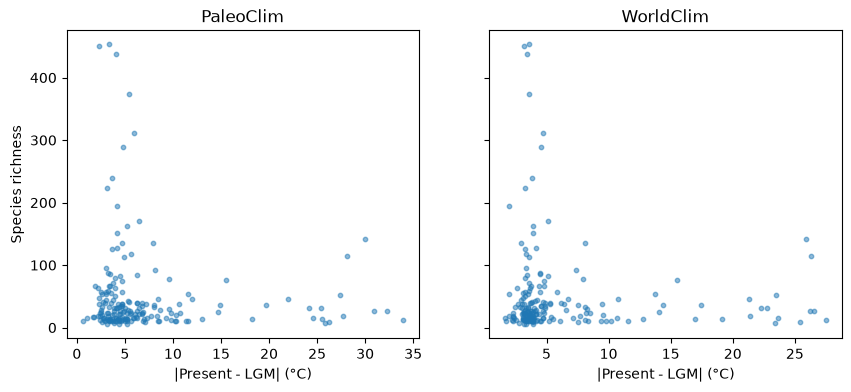

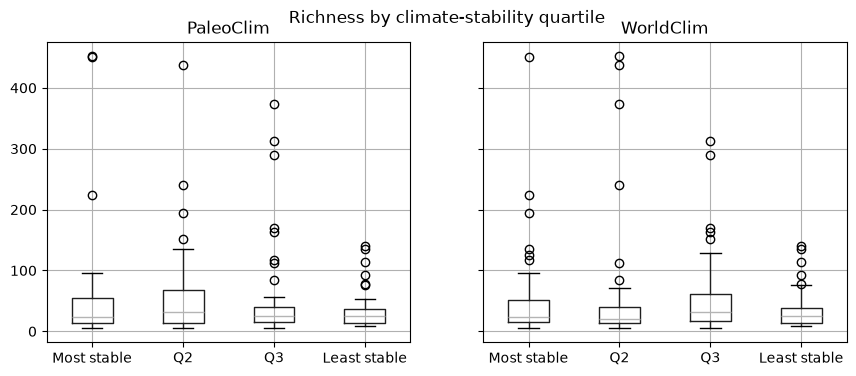

                dataset  mean  median  count
q                                           
Most stable   PaleoClim  54.0    24.0     47
Q2            PaleoClim  56.5    31.0     47
Q3            PaleoClim  53.9    25.0     47
Least stable  PaleoClim  34.3    25.0     47
Most stable   WorldClim  51.7    24.0     47
Q2            WorldClim  57.4    21.0     47
Q3            WorldClim  54.8    31.0     47
Least stable  WorldClim  34.7    26.0     47


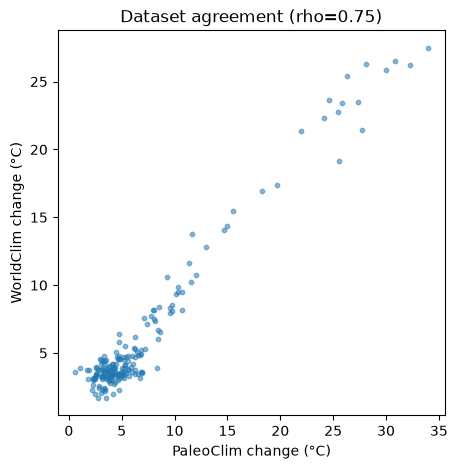

Dataset agreement rho: 0.75


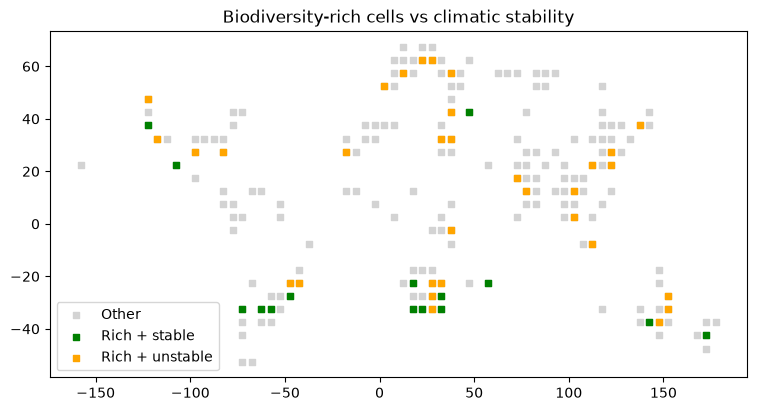

Rich+stable: 15 | Rich+unstable: 32


In [1]:
import sys
sys.path.append("..")

from common.helpers import *


MIN_REC = 10   # minimum GBIF records per cell (lower to 5 if you get < ~150 cells)

key = ["cell_lat", "cell_lon"]

gb = pd.read_csv(
    "../GBIF/processed/gbif_richness_cells.csv"
)

pc = pd.read_csv(
    "../PALEOCLIM/processed/paleoclim_cell_stability.csv"
)[
    key + ["pc_lgm_change", "pc_instability"]
]

wc = pd.read_csv(
    "../WORLDCLIM/processed/worldclim_cell_stability.csv"
)[
    key + ["wc_lgm_change", "wc_instability"]
]


df = gb.merge(
    pc,
    on=key
).merge(
    wc,
    on=key
)

print("cells after merge:", len(df))

df = df[df.n_records >= MIN_REC].copy()

df["abs_lat"] = df.cell_lat.abs()
df["log_n"] = np.log(df.n_records)

print(
    "cells analysed (>= %d records):" % MIN_REC,
    len(df)
)

df.to_csv(
    "figures/table_integrated_cells.csv",
    index=False
)


# ---------- Table 1: correlations (negative rho supports the hypothesis) ----------
rows = []

for s in ["pc", "wc"]:
    for m in ["lgm_change", "instability"]:
        c = f"{s}_{m}"

        rho, p = spearmanr(
            df[c],
            df.richness
        )

        prho, pp = partial_spearman(
            df,
            c,
            "richness",
            ["log_n", "abs_lat"]
        )

        rows.append([
            s,
            m,
            len(df),
            rho,
            p,
            prho,
            pp
        ])


tab = pd.DataFrame(
    rows,
    columns=[
        "dataset",
        "metric",
        "n",
        "rho",
        "p",
        "partial_rho",
        "partial_p"
    ]
).round(3)

tab.to_csv(
    "figures/table_correlations.csv",
    index=False
)

print(tab)


# ---------- Fig 1: scatter ----------
fig, ax = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharey=True
)

for a, s, n in zip(
    ax,
    ["pc", "wc"],
    ["PaleoClim", "WorldClim"]
):
    a.scatter(
        df[f"{s}_lgm_change"],
        df.richness,
        s=10,
        alpha=.5
    )

    a.set_title(n)
    a.set_xlabel("|Present - LGM| (°C)")


ax[0].set_ylabel("Species richness")

plt.savefig(
    "figures/int_scatter.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------- Fig 2: richness by stability quartile ----------
labels = [
    "Most stable",
    "Q2",
    "Q3",
    "Least stable"
]

fig, ax = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharey=True
)

qt = []

for a, s, n in zip(
    ax,
    ["pc", "wc"],
    ["PaleoClim", "WorldClim"]
):
    df["q"] = pd.qcut(
        df[f"{s}_lgm_change"].rank(method="first"),
        4,
        labels=labels
    )

    df.boxplot(
        "richness",
        by="q",
        ax=a
    )

    a.set_title(n)
    a.set_xlabel("")

    t = df.groupby(
        "q",
        observed=True
    ).richness.agg(
        ["mean", "median", "count"]
    ).round(1)

    t.insert(
        0,
        "dataset",
        n
    )

    qt.append(t)


fig.suptitle(
    "Richness by climate-stability quartile"
)

plt.savefig(
    "figures/int_quartiles.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------- Table 2: quartile summary ----------
qtab = pd.concat(qt)

qtab.to_csv(
    "figures/table_quartiles.csv"
)

print(qtab)


# ---------- Fig 3: agreement between datasets ----------
agree = spearmanr(
    df.pc_lgm_change,
    df.wc_lgm_change
)[0]

plt.figure(figsize=(5, 5))

plt.scatter(
    df.pc_lgm_change,
    df.wc_lgm_change,
    s=10,
    alpha=.5
)

plt.xlabel("PaleoClim change (°C)")
plt.ylabel("WorldClim change (°C)")
plt.title(f"Dataset agreement (rho={agree:.2f})")

plt.savefig(
    "figures/int_dataset_agreement.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Dataset agreement rho:",
    round(agree, 3)
)


# ---------- Fig 4: hotspot map ----------
hi_r = (
    df.richness >= df.richness.quantile(.75)
)

hi_s = (
    df.pc_lgm_change <= df.pc_lgm_change.quantile(.25)
)

plt.figure(figsize=(9, 4.5))

plt.scatter(
    df.cell_lon,
    df.cell_lat,
    c="lightgrey",
    s=15,
    marker="s",
    label="Other"
)

plt.scatter(
    df.cell_lon[hi_r & hi_s],
    df.cell_lat[hi_r & hi_s],
    c="green",
    s=25,
    marker="s",
    label="Rich + stable"
)

plt.scatter(
    df.cell_lon[hi_r & ~hi_s],
    df.cell_lat[hi_r & ~hi_s],
    c="orange",
    s=25,
    marker="s",
    label="Rich + unstable"
)

plt.legend()
plt.title("Biodiversity-rich cells vs climatic stability")

plt.savefig(
    "figures/int_hotspots.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Rich+stable:",
    int((hi_r & hi_s).sum()),
    "| Rich+unstable:",
    int((hi_r & ~hi_s).sum())
)

In [2]:
print(
    "Grid:", CELL,
    "| cells after merge:", len(gb.merge(pc, on=key).merge(wc, on=key)),
    "| analysed:", len(df),
    "| MIN_REC:", MIN_REC
)

print(
    pd.read_csv(
        "figures/table_correlations.csv"
    ).to_string(index=False)
)

print(
    pd.read_csv(
        "figures/table_quartiles.csv"
    ).to_string(index=False)
)

print(
    "Agreement rho:",
    round(agree, 3)
)

print(
    "Rich+stable:",
    int((hi_r & hi_s).sum()),
    "| Rich+unstable:",
    int((hi_r & ~hi_s).sum())
)

Grid: 5 | cells after merge: 374 | analysed: 188 | MIN_REC: 10
dataset      metric   n    rho     p  partial_rho  partial_p
     pc  lgm_change 188 -0.053 0.468       -0.207      0.004
     pc instability 188 -0.046 0.530       -0.212      0.003
     wc  lgm_change 188  0.011 0.880       -0.114      0.120
     wc instability 188  0.029 0.696       -0.102      0.163
           q   dataset  mean  median  count
 Most stable PaleoClim  54.0    24.0     47
          Q2 PaleoClim  56.5    31.0     47
          Q3 PaleoClim  53.9    25.0     47
Least stable PaleoClim  34.3    25.0     47
 Most stable WorldClim  51.7    24.0     47
          Q2 WorldClim  57.4    21.0     47
          Q3 WorldClim  54.8    31.0     47
Least stable WorldClim  34.7    26.0     47
Agreement rho: 0.75
Rich+stable: 15 | Rich+unstable: 32
